# R1 Timetable Comparison
The goal of this notebook is to compare `actual_departure` values from the R1 train line against the official schedules (`R1_direction1_schedules` and `R1_direction2_schedules`).
We will evaluate if it's viable to assign each train its scheduled time by calculating matching errors and plotting viability metrics.

In [26]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Resolve paths whether the notebook is launched from EDA/ or the repo root.
PROJECT_DIR = Path.cwd().resolve()
if not (PROJECT_DIR / "data").exists():
    PROJECT_DIR = PROJECT_DIR.parent
DATA_DIR = PROJECT_DIR / "data"
TIMETABLE_DIR = PROJECT_DIR / "EDA" / "official_timetables"

# Load official schedules
dir1_schedule = pd.read_csv(TIMETABLE_DIR / "R1_direction1_schedules.csv")
dir2_schedule = pd.read_csv(TIMETABLE_DIR / "R1_direction2_schedules.csv")

# Filter to workdays to match the Monday parquet file
dir1_schedule = dir1_schedule[dir1_schedule['Day_Type'].str.contains('Workdays|Laborables', case=False, na=False)].copy()
dir2_schedule = dir2_schedule[dir2_schedule['Day_Type'].str.contains('Workdays|Laborables', case=False, na=False)].copy()

In [27]:
dir1_schedule.head()

,L'Hospitalet de Llobregat,Barcelona Sants,Barcelona Plaça Catalunya,Barcelona Arc de Triomf,Barcelona El Clot Aragó,St. Adrià de Besòs,Badalona,Montgat,Montgat Nord,El Masnou,...,Canet de Mar,St. Pol de Mar,Calella,Pineda de Mar,Santa Susanna,Malgrat de Mar,Blanes,Tordera,Maçanet-Massanes,Day_Type
0,5.48,5.55,6.00,6.03,6.07,6.16,6.2,6.22,6.24,6.27,...,6.57,7.03,7.08,7.11,7.14,7.18,7.23,7.28,7.37,Workdays
1,5.57,6.04,6.09,6.12,6.16,6.26,6.3,6.32,6.34,6.37,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Workdays
2,6.09,6.16,6.21,6.24,6.28,6.36,6.4,6.42,6.44,6.47,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Workdays
3,6.18,6.25,6.30,6.33,6.37,6.46,6.5,6.52,6.54,6.57,...,7.27,7.33,7.38,7.41,7.44,7.48,7.53,NaN,NaN,Workdays
4,6.27,6.34,6.39,6.42,6.46,6.56,7.0,7.02,7.04,7.07,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Workdays


In [28]:
# Load parquet files (Weekday: 2026-03-17 Tuesday)
wk_parquet_timetables_path = DATA_DIR / "dynamic" / "timetables" / "timetables_2026_03_17.parquet"
df_timetables_weekday = pd.read_parquet(wk_parquet_timetables_path)
df_timetables_weekday.head()

,train_id,station_id,planned_arrival,planned_departure,actual_arrival,actual_departure,platform,stop_type,observations,timestamp,stop_sequence,composition
0,25400,79005,2026-03-16 05:50:00,2026-03-16 04:30:00,2026-03-16 06:51:00,2026-03-16 05:31:00,None,C,,2026-03-16 02:54:54,NaN,None
1,25400,79101,2026-03-16 04:30:00,2026-03-16 06:33:00,2026-03-16 05:31:00,2026-03-16 07:34:00,None,C,,2026-03-16 02:54:54,NaN,None
2,25400,79103,2026-03-16 04:37:00,2026-03-16 06:40:00,2026-03-16 05:38:00,2026-03-16 07:41:00,None,C,,2026-03-16 02:54:54,NaN,None
3,25400,79107,2026-03-16 04:50:00,2026-03-16 04:50:00,2026-03-16 05:51:00,2026-03-16 05:51:00,None,C,,2026-03-16 02:54:54,NaN,None
4,77502,78710,2026-03-16 06:20:00,2026-03-16 06:21:00,2026-03-16 06:22:00,2026-03-16 06:23:00,2,C,,2026-03-16 02:54:54,NaN,None


In [29]:
# Load parquet files (Weekday: 2026-03-17 Tuesday)
wk_parquet_trains_path = DATA_DIR / "dynamic" / "trains" / "trains_2026_03_17.parquet"
df_trains_weekday = pd.read_parquet(wk_parquet_trains_path)
df_trains_weekday.head()

,train_id,line_id,current_station_id,next_station_id,platform,status,delay_minutes,observations,timestamp,timestamp_minute,position_lat,position_lon
0,77327,R3,77111,77110,None,delayed,28,,2026-03-17 19:24:08,2026-03-17 19:24,42.025997,2.264615
1,77329,R3,77111,77105,None,delayed,22,,2026-03-17 19:24:08,2026-03-17 19:24,41.925788,2.241466
2,18133,R16,65405,71500,None,delayed,12,,2026-03-17 19:24:08,2026-03-17 19:24,40.998845,1.027175
3,18134,R16,65405,65400,None,on_time,0,AQUEST TREN FINALITZA A SANT VICENÇ DE CALDERS...,2026-03-17 19:24:08,2026-03-17 19:24,40.846766,0.661825
4,77329,R3,77107,77105,None,delayed,22,,2026-03-17 19:24:08,2026-03-17 19:24,41.820779,2.235151


In [30]:
wk_parquet_journeys_path = DATA_DIR / "dynamic" / "journeys" / "journeys_2026_03_17.parquet"
df_journeys_weekday = pd.read_parquet(wk_parquet_journeys_path)
df_journeys_weekday.head()

,journey_id,train_id,origin_station_id,destination_station_id,departure_time,arrival_time,duration,accessible,steps,timestamp
0,77502_78804_72209_2026-03-17 05:14:00,77502,78804,72209,2026-03-17 05:14:00,2026-03-17 06:00:00,00:46:00,False,1,2026-03-17 00:03:11
1,77504_78804_72209_2026-03-17 05:44:00,77504,78804,72209,2026-03-17 05:44:00,2026-03-17 06:30:00,00:46:00,False,1,2026-03-17 00:03:11
2,77702_78804_72209_2026-03-17 05:59:00,77702,78804,72209,2026-03-17 05:59:00,2026-03-17 06:48:00,00:49:00,False,1,2026-03-17 00:03:11
3,77506_78804_72209_2026-03-17 06:14:00,77506,78804,72209,2026-03-17 06:14:00,2026-03-17 07:00:00,00:46:00,False,1,2026-03-17 00:03:11
4,77704_78804_72209_2026-03-17 06:29:00,77704,78804,72209,2026-03-17 06:29:00,2026-03-17 07:18:00,00:49:00,False,1,2026-03-17 00:03:11


In [31]:
# Only keep rows where line_id is from R1 line
df_trains_weekday = df_trains_weekday[df_trains_weekday['line_id'] == 'R1'].copy()
trains_in_r1 = df_trains_weekday['train_id'].unique()
# combine values from current_station_id and next_station_id into a list of unique station_ids for each train_id
stations_in_r1 = pd.concat([df_trains_weekday['current_station_id'], df_trains_weekday['next_station_id']]).unique()
print(f"Number of unique trains in R1: {len(trains_in_r1)}")
print(f"Number of unique stations in R1: {len(stations_in_r1)}")
df_trains_weekday.head()

Number of unique trains in R1: 37
Number of unique stations in R1: 26


,train_id,line_id,current_station_id,next_station_id,platform,status,delay_minutes,observations,timestamp,timestamp_minute,position_lat,position_lon
8,77167,R1,79607,79607,None,early,-28,,2026-03-17 19:24:08,2026-03-17 19:24,41.707031,2.71944
64,25684,R1,79606,79606,None,on_time,0,,2026-03-17 19:24:08,2026-03-17 19:24,41.673534,2.76905
65,25688,R1,79606,79606,None,on_time,0,,2026-03-17 19:24:08,2026-03-17 19:24,41.673534,2.76905
66,25692,R1,79606,79606,None,on_time,0,,2026-03-17 19:24:08,2026-03-17 19:24,41.673534,2.76905
67,25694,R1,79606,79606,None,on_time,0,,2026-03-17 19:24:08,2026-03-17 19:24,41.673534,2.76905


In [32]:
wk_stations_path = DATA_DIR / "static" / "stations.parquet"
df_stations_weekday = pd.read_parquet(wk_stations_path)
# generate a dataframe mapping between station_id and name
station_id_to_name = pd.DataFrame({'station_id': df_stations_weekday['station_id'], 'station_name': df_stations_weekday['name']}).drop_duplicates().set_index('station_id')['station_name']
print(station_id_to_name)

# only keep mapping of station_id and station_name for stations in R1
station_id_to_name_r1 = station_id_to_name[station_id_to_name.index.isin(stations_in_r1)]
print(station_id_to_name_r1)
print(len(station_id_to_name_r1))

station_id
72400                Aeroport
78505      Aguilar de Segarra
73101                 Alcover
71502       Altafulla-Tamarit
78407               Anglesola
                 ...         
71700    Vilanova i la Geltrú
79410         Vilassar de Mar
73009                Vilaverd
73006                 Vimbodí
73005                 Vinaixa
Name: station_name, Length: 202, dtype: string
station_id
79600                     Arenys de Mar
79404                          Badalona
78804           Barcelona-Arc de Triomf
79009                 Barcelona-El Clot
78805      Barcelona-Plaça de Catalunya
71801                   Barcelona-Sants
79606                            Blanes
79412    Cabrera de Mar-Vilassar de Mar
79502                   Caldes d'Estrac
79603                           Calella
79601                      Canet de Mar
79407                         El Masnou
72305         L'Hospitalet de Llobregat
79605                    Malgrat de Mar
79500                            Mataró
7

In [33]:
# filter the parquet file to only keep rows where train_id is in trains_in_r1 and station_id is in stations_in_r1
df_timetables_weekday = df_timetables_weekday[df_timetables_weekday['train_id'].isin(trains_in_r1) & df_timetables_weekday['station_id'].isin(stations_in_r1)].copy()
df_timetables_weekday.head()

,train_id,station_id,planned_arrival,planned_departure,actual_arrival,actual_departure,platform,stop_type,observations,timestamp,stop_sequence,composition
217713,25663,72305,2026-03-16 17:24:00,2026-03-16 17:31:00,2026-03-16 17:40:00,2026-03-16 17:47:00,None,C,,2026-03-16 15:55:52,NaN,None
217714,25663,71801,2026-03-16 17:32:00,2026-03-16 17:47:00,2026-03-16 17:48:00,2026-03-16 18:03:00,None,C,,2026-03-16 15:55:52,NaN,None
217715,25663,78804,2026-03-16 16:45:00,2026-03-16 17:47:00,2026-03-16 17:01:00,2026-03-16 18:03:00,1,C,,2026-03-16 15:55:52,NaN,None
217716,25663,79405,2026-03-16 18:22:00,2026-03-16 16:50:00,2026-03-16 18:38:00,2026-03-16 17:06:00,1,C,,2026-03-16 15:55:52,NaN,None
217717,25663,79406,2026-03-16 16:50:00,2026-03-16 16:55:00,2026-03-16 17:06:00,2026-03-16 17:11:00,1,C,,2026-03-16 15:55:52,NaN,None


In [34]:
# only sort df_timetables_weekday by train_id 25663
# store it in a csv
# convert station_id to number in order to sort by station_id
df_timetables_weekday[df_timetables_weekday['train_id'] == "25663"].sort_values(by=['station_id', 'actual_arrival']).to_csv(PROJECT_DIR / "EDA" / "timetables_train_25663.csv", index=False)

## Mapping Stations and Filtering R1 Trains
We merge `station_id` with station names to identify trains going in Direction 1 vs Direction 2.

In [35]:
# Load stations data
stations_df = pd.read_parquet(DATA_DIR / "static" / "stations.parquet")

# Map station names to the filtered R1 timetable dataframe
df_weekday = df_timetables_weekday.merge(stations_df[['station_id', 'name']], on='station_id', how='left')

dir1_stations = dir1_schedule.columns.tolist()[:-1] # Exclude 'Day_Type'
dir2_stations = dir2_schedule.columns.tolist()[:-1] # Exclude 'Day_Type'

# Filter the parquet for only the stations that belong to R1
r1_all_stations = list(set(dir1_stations + dir2_stations))

df_r1 = df_weekday[df_weekday['name'].isin(r1_all_stations)].copy()

# Convert actual_departure to datetime and create the format time float
df_r1['departure_time'] = pd.to_datetime(df_r1['actual_departure'], errors='coerce')
df_r1['schedule_format_time'] = df_r1['departure_time'].dt.hour + (df_r1['departure_time'].dt.minute / 100.0)

# Drop records with NaT departure times
df_r1 = df_r1.dropna(subset=['schedule_format_time'])

In [36]:
# Tag train directions
def determine_direction(group):
    group = group.sort_values('stop_sequence')
    stations = group['name'].dropna().tolist()
    if len(stations) < 2: return 'Unknown'
    
    for i in range(len(stations)):
        for j in range(i+1, len(stations)):
            s1, s2 = stations[i], stations[j]
            if s1 in dir1_stations and s2 in dir1_stations:
                idx1 = dir1_stations.index(s1)
                idx2 = dir1_stations.index(s2)
                if idx1 < idx2:
                    return 'Direction 1'
                elif idx1 > idx2:
                    return 'Direction 2'
    return 'Unknown'

try:
    train_directions = df_r1.groupby('train_id').apply(determine_direction, include_groups=False).reset_index(name='direction')
except TypeError:
    train_directions = df_r1.groupby('train_id').apply(lambda g: determine_direction(g)).reset_index(name='direction')

df_r1 = df_r1.merge(train_directions, on='train_id')
print('Trains by direction:')
print(df_r1.groupby('train_id')['direction'].first().value_counts())


Trains by direction:
direction
Direction 1    21
Direction 2    16
Name: count, dtype: int64


## Batch Matching All Trains to the Timetables
We calculate the Mean Absolute Error (MAE) for every train against every valid schedule row to find the best match.

In [37]:
def clean_schedule_time(val):
    if pd.isna(val): return np.nan
    if isinstance(val, str):
        try: return float(val.replace(',', '.'))
        except: return np.nan
    return float(val)

for col in dir1_stations:
    if col in dir1_schedule.columns:
        dir1_schedule[col] = dir1_schedule[col].apply(clean_schedule_time)
        
for col in dir2_stations:
    if col in dir2_schedule.columns:
        dir2_schedule[col] = dir2_schedule[col].apply(clean_schedule_time)

def find_best_match(actual_series, schedule_df):
    # Compute difference matrix
    diff_matrix = []
    for idx, sched_row in schedule_df.iterrows():
        diffs = []
        for station in actual_series.index:
            if pd.notna(actual_series.get(station)) and pd.notna(sched_row.get(station)):
                diff = abs(actual_series[station] - sched_row[station])
                # Handle wraparound at midnight roughly
                if diff > 12: diff = 24 - diff
                diffs.append(diff)
        if diffs:
            diff_matrix.append((idx, np.mean(diffs), len(diffs)))
            
    if diff_matrix:
        # Sort by MAE, break ties by number of matching stations
        best_match = min(diff_matrix, key=lambda x: x[1])
        return best_match[0], best_match[1]
    return None, None

match_results = []
station_errors = []

# Process Direction 1
dir1_trains = df_r1[df_r1['direction'] == 'Direction 1'].drop_duplicates(subset=['train_id', 'name'])
dir1_pivot = dir1_trains.pivot(index='train_id', columns='name', values='schedule_format_time')

print("Matching Direction 1 trains...")
for train_id, row in tqdm(dir1_pivot.iterrows(), total=len(dir1_pivot)):
    best_idx, mae = find_best_match(row, dir1_schedule)
    if best_idx is not None:
        match_results.append({'train_id': train_id, 'direction': 'Direction 1', 'schedule_idx': best_idx, 'mae': mae})
        
        # Record individual station errors
        sched_row = dir1_schedule.loc[best_idx]
        for station in row.index:
            if pd.notna(row.get(station)) and pd.notna(sched_row.get(station)):
                 err = row[station] - sched_row[station]
                 # Convert hour float error roughly to minutes
                 err_minutes = err * 60
                 station_errors.append({'train_id': train_id, 'station': station, 'direction': 'Direction 1', 
                                        'actual': row[station], 'scheduled': sched_row[station], 'error_minutes': err_minutes})

# Process Direction 2
dir2_trains = df_r1[df_r1['direction'] == 'Direction 2'].drop_duplicates(subset=['train_id', 'name'])
dir2_pivot = dir2_trains.pivot(index='train_id', columns='name', values='schedule_format_time')

print("Matching Direction 2 trains...")
for train_id, row in tqdm(dir2_pivot.iterrows(), total=len(dir2_pivot)):
    best_idx, mae = find_best_match(row, dir2_schedule)
    if best_idx is not None:
        match_results.append({'train_id': train_id, 'direction': 'Direction 2', 'schedule_idx': best_idx, 'mae': mae})
        
        # Record individual station errors
        sched_row = dir2_schedule.loc[best_idx]
        for station in row.index:
            if pd.notna(row.get(station)) and pd.notna(sched_row.get(station)):
                 err = row[station] - sched_row[station]
                 err_minutes = err * 60
                 station_errors.append({'train_id': train_id, 'station': station, 'direction': 'Direction 2', 
                                        'actual': row[station], 'scheduled': sched_row[station], 'error_minutes': err_minutes})

matches_df = pd.DataFrame(match_results)
errors_df = pd.DataFrame(station_errors)
print(f"Total trains matched: {len(matches_df)}")


Matching Direction 1 trains...


100%|██████████| 21/21 [00:00<00:00, 86.02it/s]


Matching Direction 2 trains...


100%|██████████| 16/16 [00:00<00:00, 101.90it/s]

Total trains matched: 37


## Viability Plots
### Plot 1: Volume Comparison (Reported vs Scheduled)
Does the number of trains stopping at each station in the actual data match the number officially scheduled?

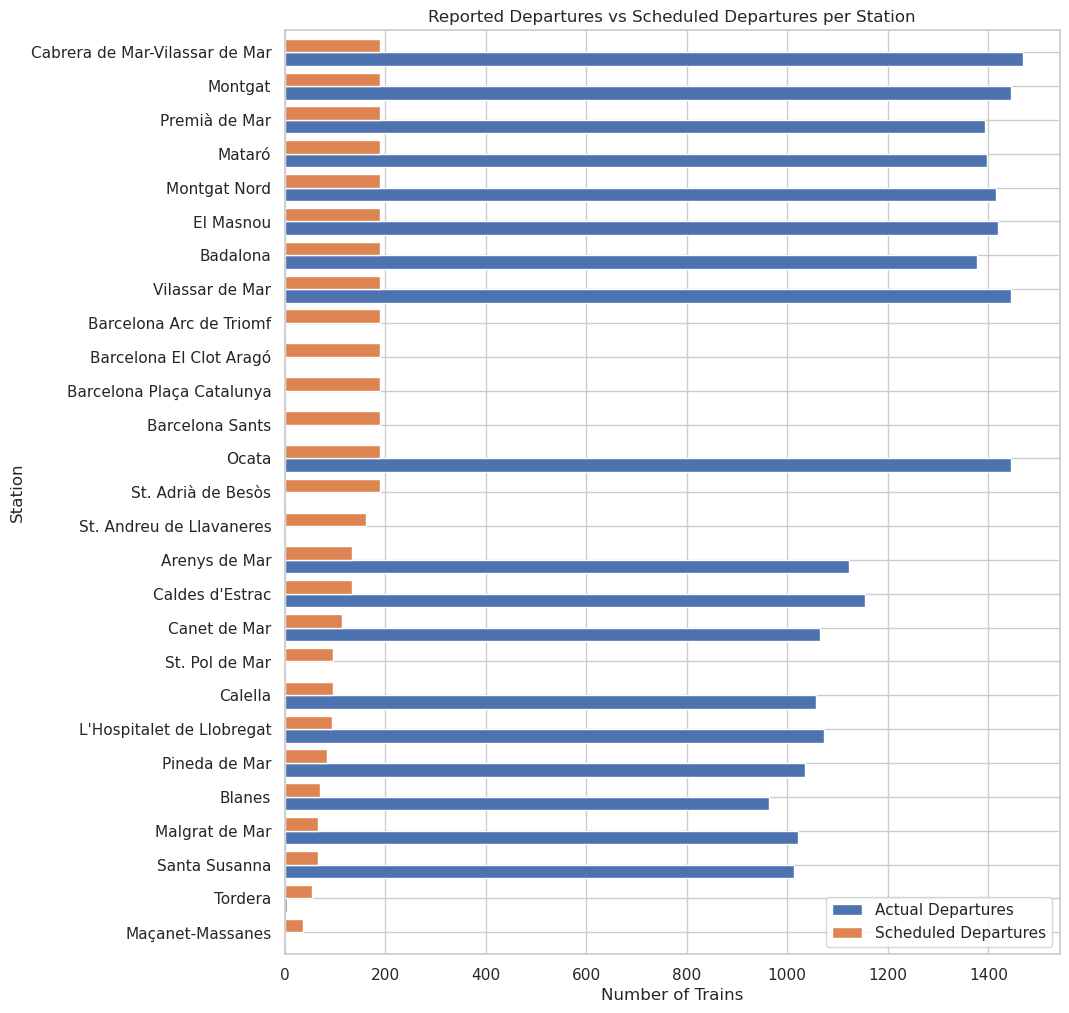

In [38]:
# Count actual departures from df_r1
actual_counts = df_r1['name'].value_counts().rename('Actual Departures')

# Count scheduled departures
sched_counts_dir1 = dir1_schedule.count().drop('Day_Type', errors='ignore')
sched_counts_dir2 = dir2_schedule.count().drop('Day_Type', errors='ignore')
sched_counts = sched_counts_dir1.add(sched_counts_dir2, fill_value=0).rename('Scheduled Departures')

volume_df = pd.concat([actual_counts, sched_counts], axis=1).fillna(0)

volume_df.sort_values('Scheduled Departures', ascending=True).plot(kind='barh', figsize=(10, 12), width=0.8)
plt.title('Reported Departures vs Scheduled Departures per Station')
plt.xlabel('Number of Trains')
plt.ylabel('Station')
plt.show()

### Plot 2: Error Distribution (MAE per Train)
Shows the distribution of average match error across all trains. An MAE of 0.10 roughly equals 6 minutes of error.

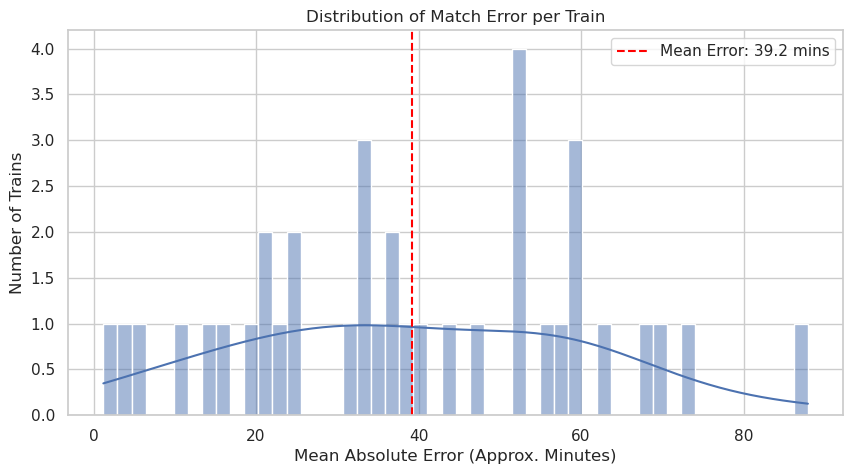

In [39]:
plt.figure(figsize=(10, 5))
sns.histplot(matches_df['mae'] * 60, bins=50, kde=True)
plt.title('Distribution of Match Error per Train')
plt.xlabel('Mean Absolute Error (Approx. Minutes)')
plt.ylabel('Number of Trains')
plt.axvline((matches_df['mae'] * 60).mean(), color='red', linestyle='--', label=f"Mean Error: {(matches_df['mae'] * 60).mean():.1f} mins")
plt.legend()
plt.show()

### Plot 3: Station-Level Errors
Are some stations systematically delayed compared to their schedule?

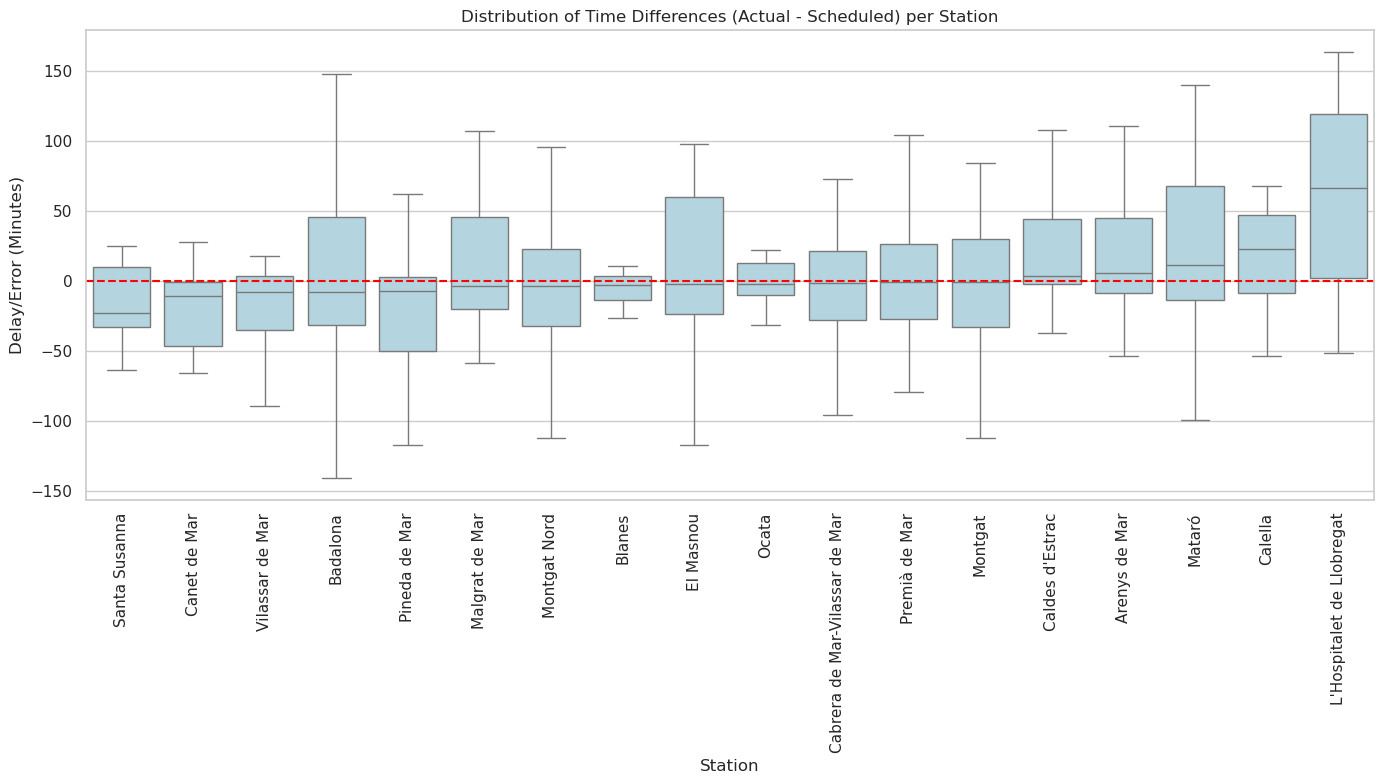

In [40]:
plt.figure(figsize=(14, 8))
# Reorder stations based on median error to spot trends
order = errors_df.groupby('station')['error_minutes'].median().sort_values().index

sns.boxplot(x='station', y='error_minutes', data=errors_df, order=order, showfliers=False, color='lightblue')
plt.xticks(rotation=90)
plt.axhline(0, color='red', linestyle='--')
plt.title('Distribution of Time Differences (Actual - Scheduled) per Station')
plt.ylabel('Delay/Error (Minutes)')
plt.xlabel('Station')
plt.tight_layout()
plt.show()